In [2]:
# %% load environment
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from torch.utils.data import DataLoader

join = os.path.join
import torch
from segment_anything import sam_model_registry
from skimage import io, transform
import torch.nn.functional as F

from monai.metrics import DiceMetric


from utils_mammo import MedSAMMammoDataset, ComposeSampleTransforms, EnsureImageChannels, ResizeSample



In [3]:
root="/home/jovyan/thesis_project"

device = "cuda:1"
ckpt = root + "/MedSAM/work_dir/MedSAM/medsam_vit_b.pth"  
model = sam_model_registry["vit_b"](checkpoint=ckpt).to(device).eval()

In [4]:
def mammo_collate_fn(batch):
    """
    Custom collate for MedSAMMammoDataset.

    Stacks:
        - image: Tensor[B, C, H, W]
        - mask: Tensor[B, 1, H, W] if all masks are tensors
        - label: Tensor[B]

    Keeps as lists:
        - bbox: list[Tensor[N_i, 4] | None]
        - path: list[str]
        - annotation_path: list[str | None]
        - metadata: list[dict] (if present)
    """
    out = {}

    # Always stack images
    out["image"] = torch.stack([sample["image"] for sample in batch], dim=0)

    # Labels
    if "label" in batch[0]:
        out["label"] = torch.stack([sample["label"] for sample in batch], dim=0)

    # Masks: stack only if all are tensors
    if "mask" in batch[0]:
        masks = [sample.get("mask", None) for sample in batch]
        if all(m is not None for m in masks):
            out["mask"] = torch.stack(masks, dim=0)
        else:
            out["mask"] = masks

    # BBoxes: keep as list because shapes vary [N_i, 4]
    if "bbox" in batch[0]:
        out["bbox"] = [sample.get("bbox", None) for sample in batch]

    # Paths
    if "path" in batch[0]:
        out["path"] = [sample.get("path", None) for sample in batch]

    if "annotation_path" in batch[0]:
        out["annotation_path"] = [sample.get("annotation_path", None) for sample in batch]

    # Metadata
    if "metadata" in batch[0]:
        out["metadata"] = [sample.get("metadata", None) for sample in batch]

    return out

In [5]:
dataset_path = Path(root + "/datasets/INbreast/INbreast Release 1.0/")
dicom_dir = dataset_path / "AllDICOMs"
xml_dir = dataset_path / "AllXML"


medsam_model_transform = ComposeSampleTransforms([
    EnsureImageChannels(3),
    ResizeSample((1024, 1024)),
])


dataset= MedSAMMammoDataset(root= dataset_path,
                           annotation_dir_name= "AllXML",
                           skip_empty_mask=True,
                           dilate_tiny_masks=True,
                           transform=medsam_model_transform)


data_loader= DataLoader(dataset, batch_size=4, shuffle=False, num_workers=0, collate_fn=mammo_collate_fn)

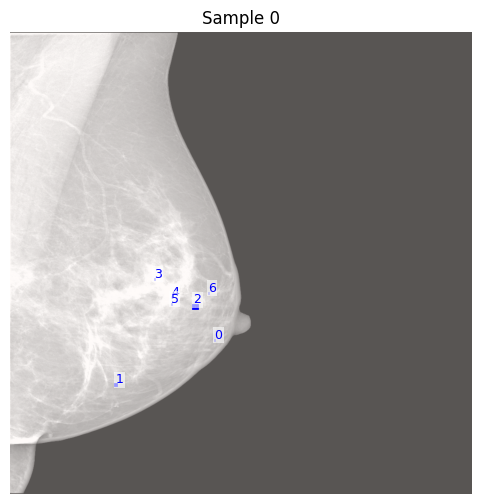

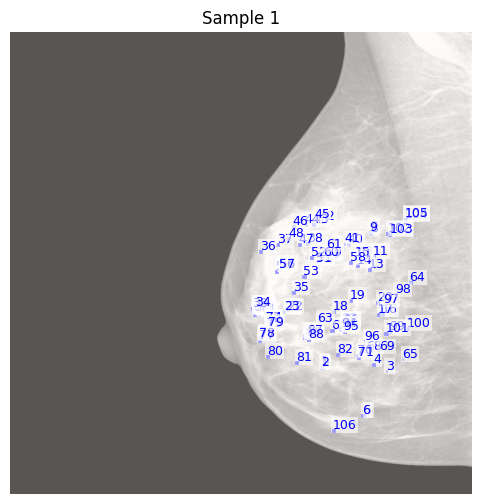

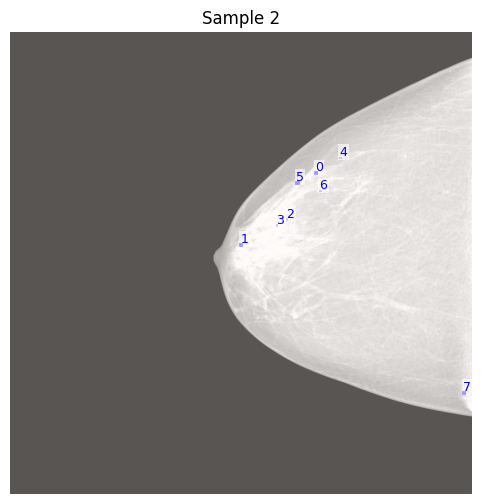

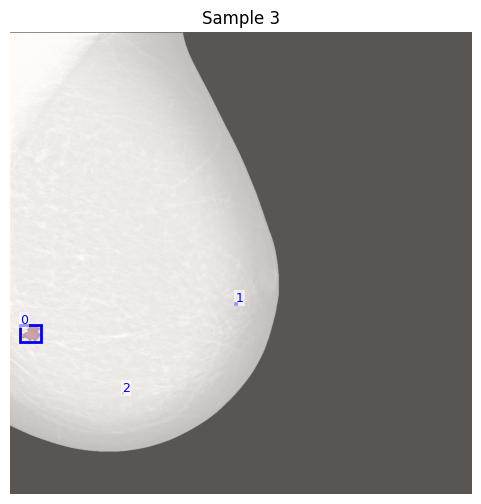

In [6]:
def show_batch(batch, n=4, mask_alpha=0.35, bbox_color="blue"):
    images = batch["image"]
    masks = batch.get("mask", None)
    bboxes = batch.get("bbox", None)

    batch_size = images.shape[0]

    for i in range(min(n, batch_size)):
        img = images[i].detach().cpu()

        # [C, H, W] -> [H, W, C]
        img = img.permute(1, 2, 0).numpy()

        # Handle grayscale vs RGB display
        if img.shape[-1] == 1:
            display_img = img.squeeze(-1)
            is_gray = True
        elif img.shape[-1] == 3:
            # If 3 channels are repeated grayscale, display as grayscale
            if np.allclose(img[..., 0], img[..., 1]) and np.allclose(img[..., 1], img[..., 2]):
                display_img = img[..., 0]
                is_gray = True
            else:
                display_img = img
                is_gray = False
        else:
            raise ValueError(f"Unexpected image shape for visualization: {img.shape}")

        fig, ax = plt.subplots(1, 1, figsize=(6, 6))

        if is_gray:
            ax.imshow(display_img, cmap="gray")
        else:
            ax.imshow(display_img)

        # Overlay mask if present
        if masks is not None:
            mask_i = masks[i]
            if mask_i is not None:
                if isinstance(mask_i, torch.Tensor):
                    mask_i = mask_i.detach().cpu().numpy()
                mask_i = np.asarray(mask_i)

                # expected [1, H, W] -> [H, W]
                if mask_i.ndim == 3 and mask_i.shape[0] == 1:
                    mask_i = mask_i[0]
                elif mask_i.ndim != 2:
                    raise ValueError(f"Unexpected mask shape for visualization: {mask_i.shape}")

                ax.imshow(mask_i, alpha=mask_alpha, cmap="Reds")

        # Draw bbox / bboxes if present
        if bboxes is not None:
            bbox_i = bboxes[i]

            if bbox_i is not None:
                if isinstance(bbox_i, torch.Tensor):
                    bbox_i = bbox_i.detach().cpu().numpy()
                bbox_i = np.asarray(bbox_i)

                # Normalize to [N, 4]
                if bbox_i.ndim == 1 and bbox_i.shape[0] == 4:
                    bbox_i = bbox_i[None, :]
                elif bbox_i.ndim == 2 and bbox_i.shape[1] == 4:
                    pass
                else:
                    raise ValueError(f"Unexpected bbox shape for visualization: {bbox_i.shape}")

                for j, (x0, y0, x1, y1) in enumerate(bbox_i):
                    rect = plt.Rectangle(
                        (x0, y0),
                        x1 - x0,
                        y1 - y0,
                        edgecolor=bbox_color,
                        facecolor="none",
                        linewidth=2,
                    )
                    ax.add_patch(rect)

                    # Optional label per box
                    ax.text(
                        x0,
                        max(0, y0 - 3),
                        f"{j}",
                        color=bbox_color,
                        fontsize=9,
                        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
                    )

        ax.set_title(f"Sample {i}")
        ax.axis("off")
        plt.show()
        
batch=next(iter(data_loader))
show_batch(batch)